## Reproduction of the RP research by Argimiro Arratia and Eduardo Sepúlveda

On the applications RQA for Financial Time Series Forecasting.


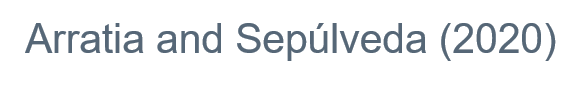

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

In [2]:
DATA_PATH = Path(r"C:\Users\skous\personal knowledge base\RQA Research"
                 r"\RecPlay\data\Goyal_Welch_2025.xlsx")

In [3]:
raw = pd.read_excel(DATA_PATH, sheet_name="Monthly", engine="openpyxl")

C:\Users\skous\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [5]:
raw["date"] = pd.to_datetime(raw["yyyymm"].astype(str), format="%Y%m")
raw = raw.set_index("date").sort_index() # sort by date

In [7]:
# A check for each month appearing only once
assert raw.index.is_unique, "Duplicate months found"

In [8]:
expected_months = pd.date_range(start=raw.index.min(), end=raw.index.max(), freq="MS")

In [10]:
assert raw.index.equals(expected_months), "Missing months found"

In [12]:
len(raw)

1860

In [15]:
raw.index.min(), raw.index.max()

(Timestamp('1871-01-01 00:00:00'), Timestamp('2025-12-01 00:00:00'))

In [16]:
raw.columns.tolist()

['yyyymm',
 'Index',
 'D12',
 'E12',
 'b/m',
 'tbl',
 'AAA',
 'BAA',
 'lty',
 'ntis',
 'Rfree',
 'infl',
 'ltr',
 'corpr',
 'svar',
 'csp',
 'CRSP_SPvw',
 'CRSP_SPvwx']

In [18]:
columns = ["Index", "D12", "tbl", "Rfree", "CRSP_SPvw"]
display(raw.loc["1990-01":"1990-05", columns])

,Index,D12,tbl,Rfree,CRSP_SPvw
date,,,,,
1990-01-01,329.08,11.142667,0.0764,0.0057,-0.067661
1990-02-01,331.89,11.230333,0.0774,0.0057,0.013381
1990-03-01,339.94,11.318000,0.0790,0.0064,0.026588
1990-04-01,330.80,11.433000,0.0777,0.0069,-0.024504
1990-05-01,361.23,11.548000,0.0774,0.0068,0.097419


In [19]:
display(raw.loc["1990":"2015", columns].isna().sum())
# No nulls

Index        0
D12          0
tbl          0
Rfree        0
CRSP_SPvw    0
dtype: int64

In [20]:
paper_gross_return = ((raw["Index"] + raw["D12"]) / raw["Index"].shift(1))

premium_candidates = pd.DataFrame({
    "Paper formula, tbl": (np.log(paper_gross_return) - np.log1p(raw["tbl"])),
    "Paper formula, Rfree": (np.log(paper_gross_return) - np.log1p(raw["Rfree"])),
    "CRSP total return, Rfree": (np.log1p(raw["CRSP_SPvw"]) - np.log1p(raw["Rfree"]))
})

In [22]:
study_candidates = premium_candidates.loc["1990":"2015"]
assert study_candidates.notna().all().all()

In [23]:
target_check = pd.DataFrame({
    "Months": study_candidates.count(),
    "Positive months": study_candidates.gt(0).sum(),
    "Positive share": study_candidates.gt(0).mean()
})

display(target_check)

,Months,Positive months,Positive share
"Paper formula, tbl",312,162,0.519231
"Paper formula, Rfree",312,232,0.743590
"CRSP total return, Rfree",312,193,0.618590


In [24]:
data = pd.DataFrame({"GSPCep": premium_candidates["Paper formula, tbl"]})
data["target"] = data["GSPCep"].gt(0).where(data["GSPCep"].notna()).astype("Int64")

In [27]:
display(data.loc["1990-01":"1990-05"])

,GSPCep,target
date,,
1990-01-01,-0.111622,0
1990-02-01,-0.032770,0
1990-03-01,-0.019317,0
1990-04-01,-0.068106,0
1990-05-01,0.044918,1


In [30]:
display(data.loc["1990":"2015", "target"].value_counts().sort_index())

target
0    150
1    162
Name: count, dtype: Int64

In [31]:
ep = data["GSPCep"]
features = pd.DataFrame({"ep": ep, "ep_lag1": ep.shift(1), "ep_lag2": ep.shift(2), "ep_sq": ep**2, "ep_sq_lag1": ep.shift(1)**2}).loc["1990":"2015"]

assert np.isfinite(features.to_numpy()).all()
display(features.head())

,ep,ep_lag1,ep_lag2,ep_sq,ep_sq_lag1
date,,,,,
1990-01-01,-0.111622,-0.021536,-0.026528,0.012460,0.000464
1990-02-01,-0.032770,-0.111622,-0.021536,0.001074,0.012460
1990-03-01,-0.019317,-0.032770,-0.111622,0.000373,0.001074
1990-04-01,-0.068106,-0.019317,-0.032770,0.004638,0.000373
1990-05-01,0.044918,-0.068106,-0.019317,0.002018,0.004638


In [34]:
window = 12
values = features.to_numpy(dtype="float32")
dates = features.index[window:]

X = np.stack([values[i-window:i] for i in range(window, len(values))])
y = data.loc[dates, "target"].to_numpy(dtype="int32")

In [35]:
np.testing.assert_allclose(X[:, -1, 0], ep.reindex(dates - pd.DateOffset(months=1)), rtol=1e-6, atol=1e-8)
assert X.shape == (300, 12, 5)

In [39]:
X.shape, y.shape, dates.min(), dates.max(), np.bincount(y)

((300, 12, 5),
 (300,),
 Timestamp('1991-01-01 00:00:00'),
 Timestamp('2015-12-01 00:00:00'),
 array([140, 160]))

In [43]:
cut, gap = int(0.8 * len(X)), window + 2
train_idx, test_idx = np.arange(cut - gap), np.arange(cut, len(X))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

y_train.mean(), y_test.mean()

(np.float64(0.4469026548672566), np.float64(0.8166666666666667))

In [44]:
def distances(x):
    return np.sqrt(np.sum((x[:, :, None, :] - x[:, None, :, :])**2, axis=-1))

upper = np.triu_indices(window, k=1)
d_train, d_test = distances(X_train), distances(X_test)
epsilon = float(np.quantile(d_train[:, upper[0], upper[1]], 0.10))
RP_train = (d_train <= epsilon).astype("float32")[..., None]
RP_test = (d_test <= epsilon).astype("float32")[..., None]

In [47]:
assert np.array_equal(RP_train[..., 0], RP_train[..., 0].transpose(0, 2, 1))

In [46]:
epsilon , RP_train.shape, RP_test.shape, RP_train[:, upper[0], upper[1], 0].mean()

(0.029869791120290756,
 (226, 12, 12, 1),
 (60, 12, 12, 1),
 np.float32(0.10009386))

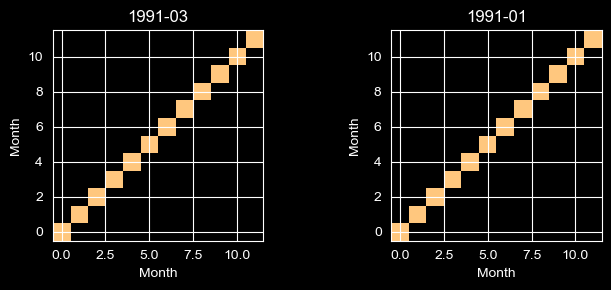

In [53]:
import matplotlib.pyplot as plt

i0 = np.flatnonzero(y_train == 0)[0]
i1 = np.flatnonzero(y_train == 1)[0]

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(RP_train[i0, :, :, 0], cmap="copper", vmin=0, vmax=1, origin="lower")
axes[1].imshow(RP_train[i1, :, :, 0], cmap="copper", vmin=0, vmax=1, origin="lower")
axes[0].set(title=f"{dates[train_idx[i0]]:%Y-%m}", xlabel="Month", ylabel="Month")
axes[1].set(title=f"{dates[train_idx[i1]]:%Y-%m}", xlabel="Month", ylabel="Month")
plt.tight_layout()
plt.show()